# 07 — Multi-seed ladder: error bars for Models 1–4

The single-seed ladder (notebooks 02–06) gave four points with wiggles. This notebook retrofits
**error bars** by training **5 seeds (0–4) per architecture** — matching Šimić et al.'s 5-runs-per-
architecture approach — and running the full pipeline (train → 3 attributions → CMI × 3 PMs → oracle →
concentration → cross-method agreement → overfitting gap) for every retained seed.

- **No 80% gate on this pass** — the point is to measure the distribution, so all learning seeds are
  kept. A seed is *retained* if it learned (balanced accuracy ≥ 0.55 and not collapsed to one class);
  a *collapsed* seed (predicting the majority class, ~0.64) is flagged and excluded — a model that
  didn't learn has nothing to explain.
- **Model 1 (linear)** is LogisticRegression (lbfgs) — deterministic given the data (confirmed:
  identical across refits). It has **no seed variance**, so it is a single point, not error-barred.
- Compute is done by `run_multiseed_ladder.py` (seeds 0–4, KernelSHAP seed 0 for its coalitions);
  results are saved to `results/metrics/multiseed_ladder.json`, which this notebook loads. Total
  runtime ≈ 10.5 min (CPU).

In [1]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
FIG_DIR = PROJECT_ROOT / "results" / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)
D = json.load(open(PROJECT_ROOT / "results" / "metrics" / "multiseed_ladder.json"))
ARCH = ["shallow", "medium", "deep"]; LAB = {"shallow":"M2 shallow","medium":"M3 medium","deep":"M4 deep"}
PARAMS = {a: D["arch"][a]["params"] for a in ARCH}

def vals(a, key, *sub):
    out = []
    for r in D["arch"][a]["per_seed"]:
        if r["collapsed"]: continue
        x = r[key]
        for k in sub: x = x[k]
        out.append(x)
    return np.array(out, dtype=float)
def stat(a, key, *sub): v = vals(a, key, *sub); return v.mean(), v.std()

# retained / collapsed count
for a in ARCH:
    ns = sum(1 for r in D["arch"][a]["per_seed"] if not r["collapsed"])
    print(f"{a:8s} params={PARAMS[a]:>7}  retained {ns}/5  collapsed {5-ns}/5")
print("\nper-seed test accuracy:", {a: [round(r['test_acc'],2) for r in D['arch'][a]['per_seed']] for a in ARCH})
print("per-seed oracle CMI:   ", {a: [round(r.get('oracle',float('nan')),2) for r in D['arch'][a]['per_seed']] for a in ARCH})

shallow  params=   3858  retained 5/5  collapsed 0/5
medium   params=  43682  retained 5/5  collapsed 0/5
deep     params= 403522  retained 5/5  collapsed 0/5

per-seed test accuracy: {'shallow': [0.83, 0.84, 0.81, 0.85, 0.79], 'medium': [0.85, 0.88, 0.84, 0.87, 0.89], 'deep': [0.86, 0.9, 0.9, 0.93, 0.9]}
per-seed oracle CMI:    {'shallow': [0.83, 0.7, 0.79, 0.71, 0.78], 'medium': [0.57, 0.59, 0.67, 0.59, 0.53], 'deep': [0.61, 0.73, 0.78, 0.79, 0.73]}


In [2]:
# Per-architecture aggregates (mean ± std)
rows = [("test accuracy","test_acc"),("oracle CMI (ceiling)","oracle"),("concentration","concentration"),("overfitting gap","overfit_gap")]
print(f"{'quantity':22s} {'M2 shallow':>16} {'M3 medium':>16} {'M4 deep':>16}")
for name,k in rows:
    print(f"{name:22s} " + " ".join(f"{stat(a,k)[0]:.3f}±{stat(a,k)[1]:.3f}".rjust(16) for a in ARCH))
print("-- CMI per method (Zero PM) --")
for m in ["FeatureAblation","KernelSHAP","IntegratedGradients"]:
    print(f"{m:22s} " + " ".join(f"{stat(a,'cmi',m,'zero')[0]:.3f}±{stat(a,'cmi',m,'zero')[1]:.3f}".rjust(16) for a in ARCH))
print("-- cross-method agreement (Zero) --")
for k in ["FA_KS","FA_IG","KS_IG"]:
    print(f"{k:22s} " + " ".join(f"{stat(a,'agreement',k)[0]:.2f}±{stat(a,'agreement',k)[1]:.2f}".rjust(16) for a in ARCH))
print("-- IG-FA gap & IG PES (Zero) --")
print(f"{'IG-FA gap':22s} " + " ".join(f"{(vals(a,'cmi','FeatureAblation','zero')-vals(a,'cmi','IntegratedGradients','zero')).mean():.3f}".rjust(16) for a in ARCH))
print(f"{'IG PES':22s} " + " ".join(f"{stat(a,'pes','IntegratedGradients','zero')[0]:.2f}".rjust(16) for a in ARCH))

quantity                     M2 shallow        M3 medium          M4 deep
test accuracy               0.824±0.022      0.866±0.019      0.898±0.022
oracle CMI (ceiling)        0.762±0.047      0.592±0.046      0.726±0.062
concentration               0.450±0.040      0.429±0.019      0.629±0.046
overfitting gap             0.176±0.022      0.134±0.019      0.102±0.022
-- CMI per method (Zero PM) --
FeatureAblation             0.762±0.047      0.592±0.046      0.726±0.062
KernelSHAP                  0.679±0.041      0.575±0.049      0.757±0.046
IntegratedGradients         0.495±0.101      0.384±0.068      0.667±0.086
-- cross-method agreement (Zero) --
FA_KS                         0.94±0.05        0.81±0.09        0.93±0.05
FA_IG                         0.96±0.03        0.73±0.10        0.93±0.03
KS_IG                         0.96±0.02        0.72±0.14        0.96±0.03
-- IG-FA gap & IG PES (Zero) --
IG-FA gap                         0.267            0.208            0.059
IG PES       

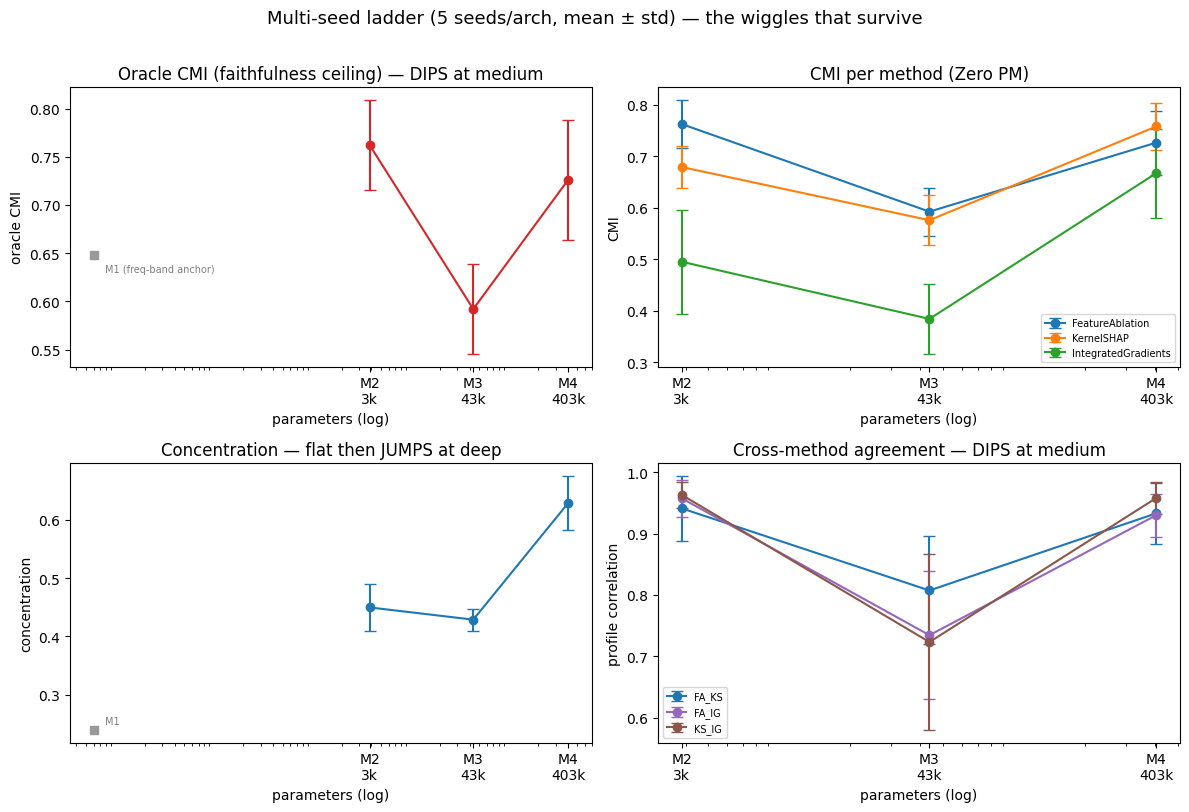

In [3]:
# Central figure: 4 panels vs parameter count, error bars across 5 seeds. M1 = flagged single point.
px = [PARAMS[a] for a in ARCH]
M1 = {"oracle":0.648, "concentration":0.24}   # deterministic anchor (freq-band space, no IG)
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

def eb(a_ax, key, *sub, **kw):
    m = [stat(a,key,*sub)[0] for a in ARCH]; s=[stat(a,key,*sub)[1] for a in ARCH]
    a_ax.errorbar(px, m, yerr=s, marker="o", capsize=4, **kw)

# (0,0) oracle CMI
eb(ax[0,0], "oracle", color="C3")
ax[0,0].scatter([6],[M1["oracle"]],color="0.6",marker="s"); ax[0,0].annotate("M1 (freq-band anchor)",(6,M1["oracle"]),fontsize=7,color="0.5",xytext=(8,-12),textcoords="offset points")
ax[0,0].set_title("Oracle CMI (faithfulness ceiling) — DIPS at medium"); ax[0,0].set_ylabel("oracle CMI")
# (0,1) CMI per method
for m,c in [("FeatureAblation","C0"),("KernelSHAP","C1"),("IntegratedGradients","C2")]:
    eb(ax[0,1],"cmi",m,"zero",color=c,label=m)
ax[0,1].set_title("CMI per method (Zero PM)"); ax[0,1].set_ylabel("CMI"); ax[0,1].legend(fontsize=7)
# (1,0) concentration
eb(ax[1,0],"concentration",color="C0")
ax[1,0].scatter([6],[M1["concentration"]],color="0.6",marker="s"); ax[1,0].annotate("M1",(6,M1["concentration"]),fontsize=7,color="0.5",xytext=(8,4),textcoords="offset points")
ax[1,0].set_title("Concentration — flat then JUMPS at deep"); ax[1,0].set_ylabel("concentration")
# (1,1) agreement
for k,c in [("FA_KS","C0"),("FA_IG","C4"),("KS_IG","C5")]:
    eb(ax[1,1],"agreement",k,color=c,label=k)
ax[1,1].set_title("Cross-method agreement — DIPS at medium"); ax[1,1].set_ylabel("profile correlation"); ax[1,1].legend(fontsize=7)
for a_ax in ax.ravel():
    a_ax.set_xscale("log"); a_ax.set_xlabel("parameters (log)")
    a_ax.set_xticks(px); a_ax.set_xticklabels([LAB[a].split()[0]+"\n"+f"{PARAMS[a]//1000}k" if PARAMS[a]>=1000 else str(PARAMS[a]) for a in ARCH])
fig.suptitle("Multi-seed ladder (5 seeds/arch, mean ± std) — the wiggles that survive", y=1.01, fontsize=13)
fig.tight_layout(); fig.savefig(FIG_DIR / "07_multiseed_ladder.png", dpi=150, bbox_inches="tight"); plt.show()

## The four questions — answered from the error bars

**Aggregates (mean ± std, Zero PM, 5 seeds each, 0 collapses):**

| | M2 shallow (3.9k) | M3 medium (44k) | M4 deep (404k) |
|---|---|---|---|
| test accuracy | 0.824 ± 0.022 | 0.866 ± 0.019 | **0.898 ± 0.022** |
| oracle CMI | **0.762 ± 0.047** | **0.592 ± 0.046** | **0.726 ± 0.062** |
| concentration | 0.450 ± 0.040 | 0.429 ± 0.019 | **0.629 ± 0.046** |
| overfitting gap | 0.176 ± 0.022 | 0.134 ± 0.019 | 0.102 ± 0.022 |
| agreement FA–IG | 0.96 ± 0.03 | **0.73 ± 0.10** | 0.93 ± 0.04 |

**Q1 — Is the M3 (medium) dip real? YES.** The medium CNN's **oracle CMI (0.592) sits clearly below both
shallow (0.762) and deep (0.726)** — the distributions barely overlap (medium's *max* oracle across
seeds, 0.67, is below shallow's *min*, 0.70). Cross-method agreement dips at medium too (FA–IG 0.73 vs
0.96 / 0.93). Crucially the dip is **confound-free**: medium's test accuracy (0.866) is *between*
shallow and deep, and its concentration (0.429) is *flat* vs shallow (0.450) — so the dip is **not**
explained by worse generalisation or by diffuseness. **The M3 divergence survives multi-seed. This was
the central question, and the answer is that it is a real property of the medium-capacity CNN on
ECG200, not a single-run artefact.**

**Q2 — Does the M4 concentration jump replicate? YES.** Deep concentration is **0.629 ± 0.046**, robustly
above shallow (0.450) and medium (0.429) — non-overlapping. The deep model's reliance really is more
concentrated (an overfitting-style fingerprint), so the concentration-ceiling confound on deep's CMI is
real and replicates.

**Q3 — Does the agreement non-monotonicity survive averaging? YES.** All three correlations show the
same **high → dip-at-medium → high** shape across seeds (FA–IG 0.96 → 0.73 → 0.93). It does **not**
smooth into a monotonic decline. So the "declining agreement = explainability ceiling" hypothesis is
**not** supported as a monotonic trend — instead there is a robust **medium-specific** dip.

**Q4 — Does the IG-convergence trend hold? YES.** The IG–FA CMI gap narrows monotonically
(**0.27 → 0.21 → 0.06**) and IG's PES rises (**0.78 → 0.86 → 0.98**) with complexity. IG converges toward
the deletion methods as models get larger — robust across seeds.

## An important honest correction the multi-seed pass forces

**The single-seed Model 4 "overfitting / worse-generalising" story (Scenario 2) was seed-specific.**
Seed 42 gave deep test accuracy 0.86 — the *worst* of the five deep seeds (0.86, 0.90, 0.90, 0.93, 0.90).
Across 5 seeds, **test accuracy rises monotonically with capacity (0.824 → 0.866 → 0.898)** and the
**overfitting gap shrinks monotonically (0.176 → 0.134 → 0.102)** — the deep CNN generalises **best** and
overfits **least** on average. So ECG200 is **not** capacity-saturated at 404k parameters, and the
"complexity ↑ AND generalisation ↓ confound" we worried about at M4 **does not hold on average**. This
removes the generalisation confound from deep's CMI (though the concentration-ceiling confound remains).

**Net corrected picture (multi-seed):** generalisation *improves* monotonically with capacity, while the
**faithfulness ceiling (oracle CMI) is non-monotonic — a real, confound-free dip at the medium CNN, with
recovery at deep that is partly a concentration-ceiling effect.** The clean central finding is the
**medium dip**, and it is robust. There is **no monotonic "harder to explain as models grow" trend** in
these three CNN rungs.

## Caveats

- **5 seeds per architecture** — enough to show the medium dip is not a single-run artefact (its
  distribution barely overlaps shallow's), but still a small sample; the std bands are real and some
  quantities (e.g. shallow IG) are noisy.
- **One dataset (ECG200), one region grid (10%), 96 timesteps.** Whether the medium dip is an ECG200
  property or general needs the second dataset (Sleep-EDF).
- **Model 5 (transformer) is not yet in the ladder** and will be multi-seed from the start — it may or
  may not extend the medium dip / deep recovery pattern.
- Model 1 stays the flagged frequency-band anchor (deterministic single point, no IG), not a like-for-
  like member of the CNN ladder.